<a href="https://colab.research.google.com/github/jonay-lab/Assignment_Practice/blob/main/Assignment_7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Assignment_7:House Price Prediction Using Boston Housing Data**

the source : from Kaggle :Curated from multiple resources and web scrapping.
This dataset provides comprehensive information for house price prediction, with 13 column names:

This dataset provide this features
Price: The price of the house.

Area: The total area of the house in square feet.

Bedrooms: The number of bedrooms in the house.

Bathrooms: The number of bathrooms in the house.

Stories: The number of stories in the house.

Mainroad: Whether the house is connected to the main road (Yes/No).

Guestroom: Whether the house has a guest room (Yes/No).

Basement: Whether the house has a basement (Yes/No).

Hot water heating: Whether the house has a hot water heating system (Yes/No).

Airconditioning: Whether the house has an air conditioning system (Yes/No).

Parking: The number of parking spaces available within the house.

Prefarea: Whether the house is located in a preferred area (Yes/No).


Furnishing status: The furnishing status of the house (Fully Furnished, Semi-Furnished, Unfurnished).



**goal of this assignment**:

 build a regression model to predict house prices and knowing the features that affects the most

Import all the necessary libraries for data handling, visualization, and model building

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


1.Loading the data set

In [ ]:

df = pd.read_csv('/content/drive/MyDrive/Data_set/housein_boston.csv')
df.head(2)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished


check the data types and consitencty

checking missing values

In [ ]:
df.isnull().sum()

,0
price,0
area,0
bedrooms,0
bathrooms,0
stories,0
mainroad,0
guestroom,0
basement,0
hotwaterheating,0
airconditioning,0


there is no missing values in the data set.

checking data type

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


Data Preprocessing


Comparing some of numeric features with target variables

Correlation between numeric features

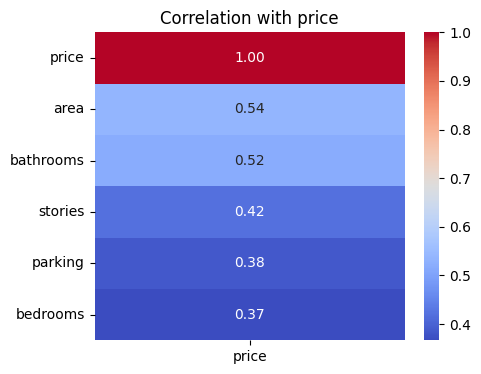

In [ ]:
corr_matrix = df.corr(numeric_only=True)
target_corr = corr_matrix[["price"]].sort_values(
    by="price",
    ascending=False)
plt.figure(figsize=(5, 4))
sns.heatmap(target_corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation with price")
plt.show()



The correlation analysis indicates that area has the strongest relationship with house price, followed by bathrooms, stories, and parking.
these features show the highest positive correlations with the target variable, suggesting they have the greatest influence on house prices.
therefore, they were selected for scatter plot visualizations to further examine their relationship with price.

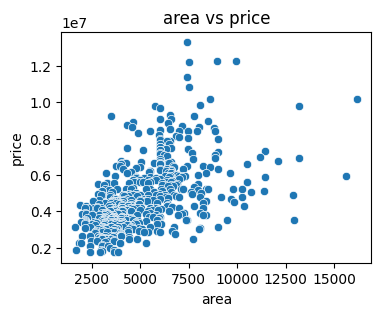

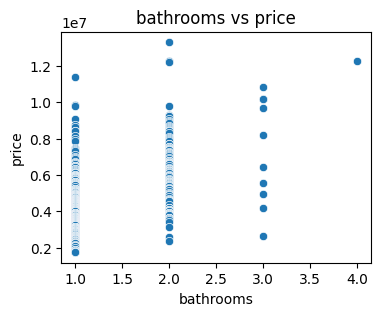

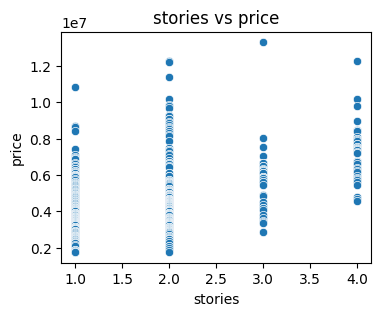

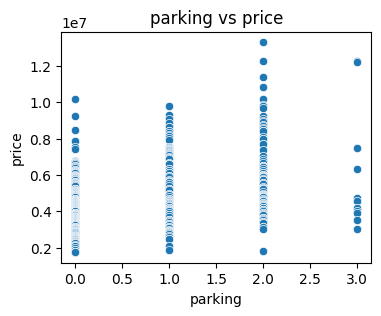

In [ ]:
features = ['area', 'bathrooms', 'stories', 'parking']
target = 'price'

for feature in features:
    plt.figure(figsize=(4, 3))
    sns.scatterplot(x=feature, y=target, data=df)
    plt.title(f'{feature} vs {target}')
    plt.show()


the scatter plots show that the relationship with price is not perfectly linear due to the presence of both low and high-priced houses.
however, there is still a clear pattern, especially between area and price, where larger houses tend to have higher prices. compared to other features, this relationship is the most noticeable.

**Data Preprocessing**

both label encoding and one hot encoding used for change to categorical data

In [ ]:
le = LabelEncoder()
df['guestroom'] = le.fit_transform(df['guestroom'])
df['basement'] = le.fit_transform(df['basement'])
df['hotwaterheating'] = le.fit_transform(df['hotwaterheating'])
df['airconditioning'] = le.fit_transform(df['airconditioning'])
df['prefarea'] = le.fit_transform(df['prefarea'])
df['mainroad'] = le.fit_transform(df['mainroad'])

df = pd.get_dummies(df, columns=['furnishingstatus'],drop_first=True)

In [ ]:
df.head(2)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,False,False
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,False,False


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 14 columns):
 #   Column                           Non-Null Count  Dtype
---  ------                           --------------  -----
 0   price                            545 non-null    int64
 1   area                             545 non-null    int64
 2   bedrooms                         545 non-null    int64
 3   bathrooms                        545 non-null    int64
 4   stories                          545 non-null    int64
 5   mainroad                         545 non-null    int64
 6   guestroom                        545 non-null    int64
 7   basement                         545 non-null    int64
 8   hotwaterheating                  545 non-null    int64
 9   airconditioning                  545 non-null    int64
 10  parking                          545 non-null    int64
 11  prefarea                         545 non-null    int64
 12  furnishingstatus_semi-furnished  545 non-null    b


The data is clean, well-structured, and ready for model building. all variables are in the correct format, and there are no missing or inconsistent values that could affect the training process.

**Splitting the data set**

In [ ]:

feature =['area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
       'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
       'parking', 'prefarea', 'furnishingstatus_semi-furnished',
       'furnishingstatus_unfurnished']
X = df[feature]
y = df['price']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)


**STEP 6: Build Model & Evaluate the model**

DecisionTreeRegressor model

In [ ]:
dt_model = DecisionTreeRegressor(max_depth=5, random_state=42)
dt_scores = cross_val_score(dt_model, X_train, y_train, cv=5, scoring='r2')
print("Decision Tree CV R2 Scores:", dt_scores)
print("Mean CV R2:", dt_scores.mean())
dt_model.fit(X_train, y_train)
y_pred_dt = dt_model.predict(X_test)
print("R2 Score:", r2_score(y_test, y_pred_dt))
print("MAE:", mean_absolute_error(y_test, y_pred_dt))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_dt)))

Decision Tree CV R2 Scores: [0.1678019  0.47019128 0.48000161 0.419319   0.40505531]
Mean CV R2: 0.38847381793611335
R2 Score: 0.4601867372826932
MAE: 1236033.7283084097
RMSE: 1651824.4629261515



The Decision Tree model shows moderate performance in predicting house prices. the cross-validation R² scores vary between 0.17 and 0.48,indicating inconsistency across different data splits. the mean CV R² of 0.39 suggests the model explains only about 39% of the variation in prices during validation. the test R² score 0.46 is slightly better but still shows limited predictive accuracy. the MAE  of bout 1.24 million  and RMSE of 1.65 million indicate relatively large prediction errors, including some significant outliers. overall, the model captures some patterns in the data but is not highly accurate or stable and could be improved further.

Random forest model

In [ ]:
rf_model = RandomForestRegressor(n_estimators=200, max_depth=8, random_state=42)
rf_scores = cross_val_score(rf_model, X_train, y_train, cv=5, scoring='r2')
print("RF CV R2 Scores:", rf_scores)
print("Mean CV R2:", rf_scores.mean())

rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

print("R2 Score:", r2_score(y_test, y_pred_rf))
print("MAE:", mean_absolute_error(y_test, y_pred_rf))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_rf)))

RF CV R2 Scores: [0.56208609 0.67035946 0.58413075 0.58345085 0.57909199]
Mean CV R2: 0.5958238296783445
R2 Score: 0.6101359614698834
MAE: 1022545.0034197
RMSE: 1403778.8890277457


The random forest model shows good and stable performance compared to previous models. the cross-validation R² scores range from 0.56 to 0.67 , which indicates that, on average, predictions deviate by around 1 million unites, which is lower than the Decision Tree error and shows better accuracy . the RMSE of about 1.4 million is also lower, meaning the model has fewer larger prediction errors compared to before.
over all , the random forest model performs better and more reliably than Decision Tree